In [29]:
from pathlib import Path
import dask.dataframe as dd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
chunks_folderpath = Path("../data/silver/ghana-2021-chunks")
ddf = dd.read_parquet(chunks_folderpath / "*.parquet")
print("# rows:", len(ddf))

# rows: 242071


In [31]:
# Load a sample 
ddf.sample(frac=20_000/len(ddf))
df = ddf.compute().reset_index(drop=True)

In [32]:
# Cleanup
df = df.rename(columns={'ethz_map': 'y'})
df['y'] = df.y > 0.65 # max F1 as per the ETHZ paper
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,scene_classification,valid_observations,y
0,-0.273906,11.165903,34,34,31,36,2,34,28,37,...,0,0,0,0,0,0,0,5,7,False


In [33]:
# Convert bands to 0-1 values
band_cols = [e for e in df.columns if e not in ('lon', 'lat', 'y')]
band_cols = [e for e in band_cols if not any(e.startswith(prefix) for prefix in ('cloud_confidence', 'scene_classification', 'valid_observations'))]
df[band_cols] /= 255
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,scene_classification,valid_observations,y
0,-0.273906,11.165903,0.133333,0.133333,0.121569,0.141176,0.007843,0.133333,0.109804,0.145098,...,0,0,0,0,0,0,0,5,7,False


# Spatially-split train test

In [34]:
def split(df, n_folds: int = 100):
    """Create n_folds spatially"""

    # Compute spatial folds
    kmeans = KMeans(n_clusters=n_folds, random_state=42, n_init=10)
    return kmeans.fit_predict(df[['lat', 'lon']])
    
fold_idxs  = split(df)

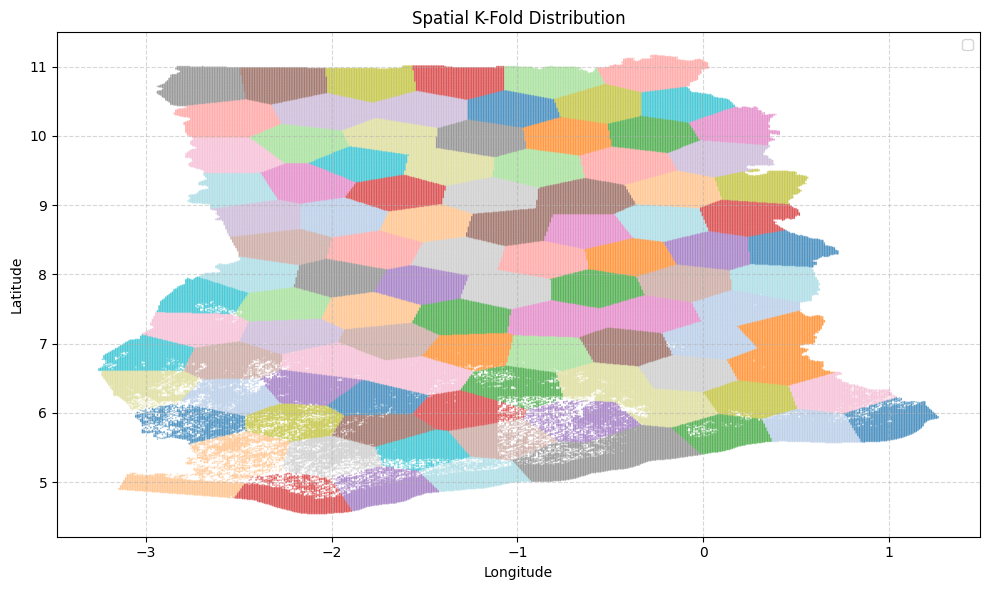

In [35]:
# Plot the folds
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='lon', y='lat', hue=fold_idxs, palette='tab20', s=1, alpha=0.5, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [36]:
import pandas as pd

Xy_folderpath = Path('../data/silver/Xy-2021')
Xy_folderpath.mkdir(exist_ok=True)

# Figure out test folds
test_size = 0.1
n_test_folds = int(np.ceil(len(np.unique(fold_idxs)) * test_size))
test_fold_idxs = np.random.choice(np.unique(fold_idxs), replace=False, size=n_test_folds)

# Split train:test
test_mask = np.isin(fold_idxs, test_fold_idxs)
df['fold_idx'] = fold_idxs
train_df = df[~test_mask]
test_df = df[test_mask]

# Build Xy
Xy_train = train_df.drop(columns=['lat', 'lon', 'fold_idx'])
Xy_test = test_df.drop(columns=['lat', 'lon', 'fold_idx']) 

# Built split data to keep track of what is where
track_train_df = train_df[['lat', 'lon', 'fold_idx']]
track_test_df = test_df[['lat', 'lon', 'fold_idx']]
    
# Dump to disk the split
track_train_df.to_parquet(Xy_folderpath / "track_train_df.parquet")
Xy_train.to_parquet(Xy_folderpath / "Xy_train.parquet")
track_test_df.to_parquet(Xy_folderpath / "track_test_df.parquet")
Xy_test.to_parquet(Xy_folderpath / "Xy_test.parquet")

/tmp/ipykernel_55446/3400516426.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fold_idx'] = fold_idxs
